In [1]:
import scanpy as sc
import os

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
import phate
import sys
from tqdm import tqdm
import seaborn as sns 
# Import the modules themselves
import torchcfm.conditional_flow_matching as cfm
import torchcfm.models as models
import torchcfm.utils as utils
from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

# Running axolot with PCA embeddings

In [3]:
folder_path = "/home/mcb/users/msandl4/data/axolotl/"

In [4]:
from pathlib import Path
import re
folder = Path(folder_path)

In [6]:
def extract_daynum(f):
    """Extract leading number from filename stem like '2DPI_1' -> 2, '10DPI_1' -> 10"""
    match = re.match(r'(\d+)', f.stem)
    if match:
        return int(match.group(1))
    else:
        return float('inf')

files = sorted(folder.glob("*.h5ad"), key=extract_daynum)
adatas = [sc.read_h5ad(f) for f in files]

batch_numbers = [extract_daynum(f) for f in files]


In [7]:
for adata in adatas:
    if 'counts' in adata.layers:
        adata.X = adata.layers['counts'].copy()

In [9]:
adata_merged = sc.concat(
    adatas,
    join='outer',
    label='timepoint',
    keys=batch_numbers,
    fill_value=0,
    merge='unique', # This helps keep obsm/varm if they are consistent,
    uns_merge='unique'
)
adata_merged.obs_names_make_unique()

/home/mcb/users/msandl4/.conda/envs/torchcfm/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
sc.pp.normalize_total(adata_merged, target_sum=1e4)
sc.pp.log1p(adata_merged)
sc.pp.highly_variable_genes(adata_merged, n_top_genes=2000, flavor='seurat', batch_key='timepoint')
adata_merged = adata_merged[:, adata_merged.var['highly_variable']]

In [11]:
sc.tl.pca(adata_merged, n_comps=50, svd_solver='arpack')

/home/mcb/users/msandl4/.conda/envs/torchcfm/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


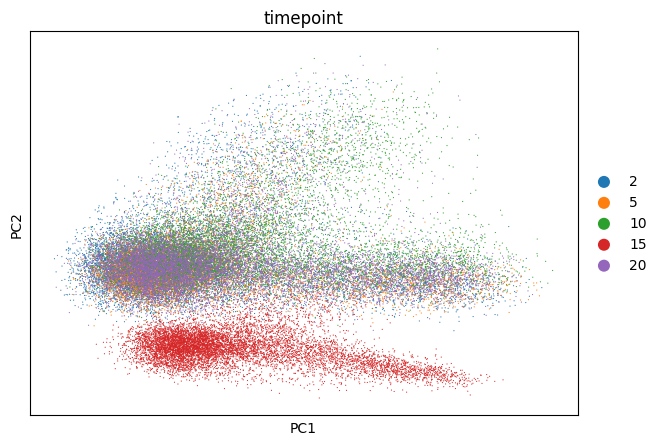

In [12]:
sc.pl.scatter(adata_merged, basis="pca", color="timepoint")

In [13]:
adata_merged.obs["timepoint"]
timepoints = sorted(adata_merged.obs['timepoint'].unique())
print(timepoints)
n_times = len(timepoints)
# Standardize coordinates

X = [
    adata_merged.obsm["X_pca"][adata_merged.obs["timepoint"] == t]
    for t in timepoints
]

[2, 5, 10, 15, 20]


In [30]:
import scprep


def plot_trajectories(traj, legend=True):
    n = 2000
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    scprep.plot.scatter(
        adata_merged.obsm["X_pca"][:, 0],
        adata_merged.obsm["X_pca"][:, 1],
        title = "CFM trajectories",
        c=adata_merged.obs["timepoint"],
        ax=ax,
    )
    # ax.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    ax.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    # ax.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")

    for i in range(15):
        ax.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    # plt.xticks([])
    # plt.yticks([])
    # plt.axis("off")


def get_batch(FM, X, batch_size, n_times, return_noise=False):
    """Construct a batch with point sfrom each timepoint pair"""
    ts = []
    xts = []
    uts = []
    noises = []
    for t_start in range(n_times - 1):
        x0 = (
            torch.from_numpy(X[t_start][np.random.randint(X[t_start].shape[0], size=batch_size)])
            .float()
            .to(device)
        )
        x1 = (
            torch.from_numpy(
                X[t_start + 1][np.random.randint(X[t_start + 1].shape[0], size=batch_size)]
            )
            .float()
            .to(device)
        )
        if return_noise:
            t, xt, ut, eps = FM.sample_location_and_conditional_flow(
                x0, x1, return_noise=return_noise
            )
            noises.append(eps)
        else:
            t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1, return_noise=return_noise)
        ts.append(t + t_start)
        xts.append(xt)
        uts.append(ut)
    t = torch.cat(ts)
    xt = torch.cat(xts)
    ut = torch.cat(uts)
    if return_noise:
        noises = torch.cat(noises)
        return t, xt, ut, noises
    return t, xt, ut

In [15]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 256
n_times = len(timepoints)

In [16]:
def train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000):
    for i in tqdm(range(10000)):
        ot_cfm_optimizer.zero_grad()
        t, xt, ut = get_batch(FM, X, batch_size, n_times)
        vt = ot_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        ot_cfm_optimizer.step()

In [17]:
def plot_node_path(ot_cfm_model, X):
    node = NeuralODE(torch_wrapper(ot_cfm_model), solver="dopri5", sensitivity="adjoint")
    with torch.no_grad():
        traj = node.trajectory(
            torch.from_numpy(X[0][:1000]).float().to(device),
            t_span=torch.linspace(0, n_times - 1, 400),
        ).cpu()
        plot_trajectories(traj.cpu().numpy())

In [20]:
sigma = 0.3
dim = adata_merged.obsm["X_pca"].shape[1] 
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma, method="prior", prior_method="basic_entropic_ot")
train_model(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [02:35<00:00, 64.24it/s]


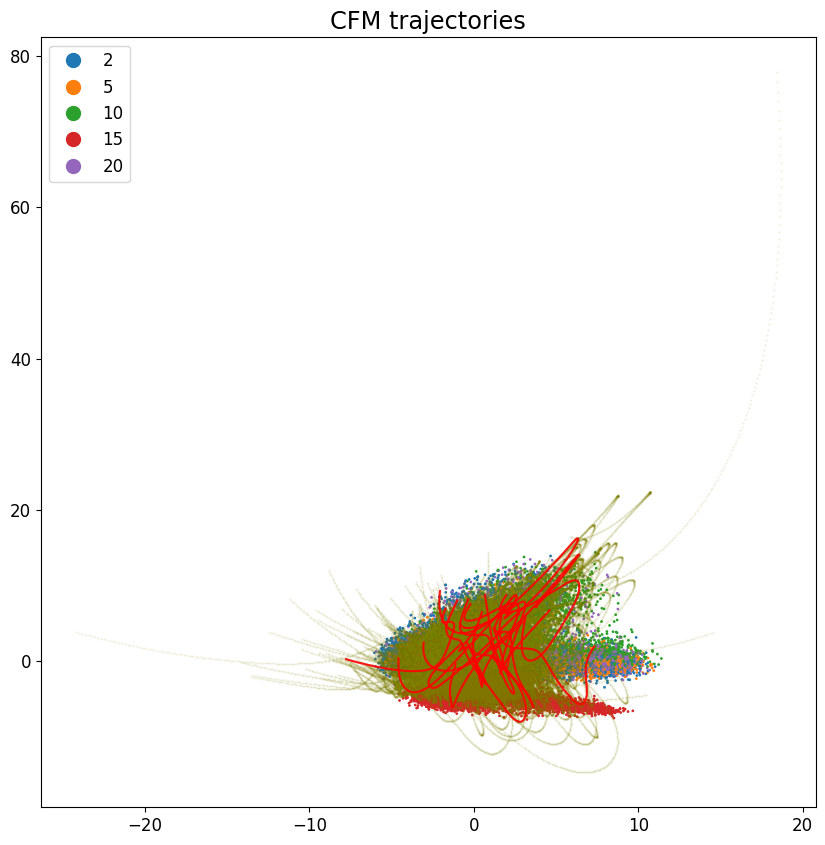

In [21]:
plot_node_path(ot_cfm_model, X)

Basic entropic OT is quite messy as seen above

In [22]:
dv_map = {'V': 0.0, 'D': 1.0}

# 2. Map injury positions to a gradient
# We'll put 'NO' at one end, and the injury labels in the middle/other end
ml_map = {
    'NO': 0.0, 
    'inj_D_LP': 0.5, 
    'inj_D_MP': 1.0,
    np.nan: 0.0  # Handling that NaN! We'll treat it as 'NO' or 0.5
}

# 3. Apply the mapping to the AnnData object
import numpy as np
adata_merged.obs['DV_num'] = adata_merged.obs['D_V'].map(dv_map).astype(float)
adata_merged.obs['ML_num'] = adata_merged.obs['inj_M_L'].map(ml_map).astype(float)

# 4. Fill any remaining NaNs just in case
adata_merged.obs['DV_num'] = adata_merged.obs['DV_num'].fillna(0.5)
adata_merged.obs['ML_num'] = adata_merged.obs['ML_num'].fillna(0.0)

In [23]:
time_data = [adata_merged[adata_merged.obs['timepoint'] == tp] for tp in timepoints]
from sklearn.metrics import pairwise_distances


def get_batch_spatial(FM, X, batch_size, n_times, return_noise=False):
    """Construct a batch with point sfrom each timepoint pair"""
    ts = []
    xts = []
    uts = []
    Ds = []
    noises = []
    coords = [
        adata_t.obs[['DV_num', 'ML_num']].values 
        for adata_t in time_data
    ]
    for t_start in range(n_times - 1):
        idx0 = np.random.randint(X[t_start].shape[0], size=batch_size)
        idx1 = np.random.randint(X[t_start+1].shape[0], size=batch_size)

        x0 = torch.from_numpy(X[t_start][idx0]).float().to(device)
        x1 = torch.from_numpy(X[t_start+1][idx1]).float().to(device)

        c0 = coords[t_start][idx0]
        c1 = coords[t_start+1][idx1]

        if return_noise:
            t, xt, ut, eps = FM.sample_location_and_conditional_flow(
                x0, x1, return_noise=return_noise
            )
            noises.append(eps)
        else:
             # compute spatial prior
            D_spatial = pairwise_distances(c0, c1, metric='sqeuclidean')
            
            # 6. Compute Expression Distance (Matching what the notebook does)
            #D_expression = pairwise_distances(X[t_start][idx0], X[t_start+1][idx1], metric='sqeuclidean')
            
            # 7. Combine them: The Fused Cost Matrix
            #D = (1 - alpha) * D_expression + alpha * D_spatial
            D = D_spatial
            # Convert to torch for the FM sampler
            #D = torch.from_numpy(D).float().to(device)
            

            # sample conditional flow
            t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1, D=D)
        ts.append(t + t_start)
        xts.append(xt)
        uts.append(ut)
    t = torch.cat(ts)
    xt = torch.cat(xts)
    ut = torch.cat(uts)
    #Ds = torch.stack(Ds)
    if return_noise:
        noises = torch.cat(noises)
        return t, xt, ut, noises
    return t, xt, ut



In [24]:
def train_model_custom_prior(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000):
    for i in tqdm(range(10000)):
        ot_cfm_optimizer.zero_grad()
        t, xt, ut = get_batch_spatial(FM, X, batch_size, n_times)
        vt = ot_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        ot_cfm_optimizer.step()

In [26]:
sigma = 0.3
dim = adata_merged.obsm["X_pca"].shape[1] 
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma, method="prior", prior_method="spatial")
train_model_custom_prior(ot_cfm_optimizer, FM, batch_size, n_times, X, ot_cfm_model, max_iters=10000)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:29<00:00, 47.64it/s]


In [32]:
def plot_trajectories(traj, legend=True):
    n = 100
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    scprep.plot.scatter(
        adata_merged.obsm["X_pca"][:, 0],
        adata_merged.obsm["X_pca"][:, 1],
        title = "CFM trajectories",
        c=adata_merged.obs["timepoint"],
        ax=ax,
    )
    # ax.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    ax.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    # ax.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")

    for i in range(15):
        ax.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    # plt.xticks([])
    # plt.yticks([])
    # plt.axis("off")


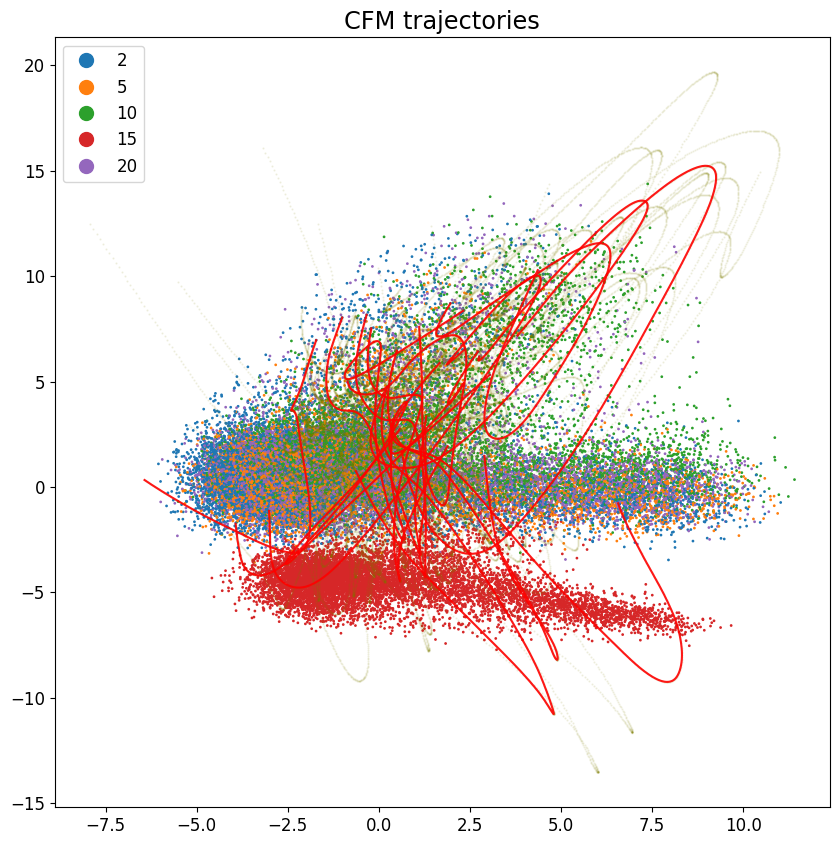

In [33]:
plot_node_path(ot_cfm_model, X)

Hard to tell on PCA..